# Deepfake Detection  
## Part 1: Traditional Handcrafted Features Baseline (863 videos only)

## the dataset
it is from kaggle https://www.kaggle.com/datasets/sanikatiwarekar/deep-fake-detection-dfd-entire-original-dataset

**Goal of this notebook**  
We will explore the **DFD dataset** (FaceForensics-style) visually and mathematically to understand **why deepfakes look real to the human eye but leave detectable traces**.

We will:
- Look at raw frames, temporal stability, and compression artifacts (ELA)
- Crop faces (artifacts live in the face!)
- Extract rich traditional features (multi-frame LBP + HOG + Color stats)
- Train classical ML (Random Forest & SVM)
- See why texture/edge features get ~65–75% at best → perfect motivation for CNN+LSTM in another notebook



In [1]:
# Imports
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.feature import local_binary_pattern, hog
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import seaborn as sns

# Face detector (built-in in Colab)
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

print(" All libraries loaded. Ready for the story!")

 All libraries loaded. Ready for the story!


## Step 1: Loading the Dataset & Creating a Balanced 200-Video Subset

We already have the metadata file from before.  
We now create a clean, balanced subset of exactly 100 real + 100 fake videos.

In [13]:
# Secure API Credentials
import os
from getpass import getpass

# This creates a secure input box so you don't have to edit the code
os.environ['KAGGLE_USERNAME'] = input(': ')
os.environ['KAGGLE_KEY'] = getpass(': ')

print("Credentials set successfully!")

: u
: ··········
Credentials set successfully!


In [3]:
#  Dependencies & Dataset Download
!pip install -q kaggle opencv-python-headless matplotlib seaborn pandas numpy scipy
print("Downloading DFD Dataset (FaceForensics++ variant)...")

!kaggle datasets download -d sanikatiwarekar/deep-fake-detection-dfd-entire-original-dataset
!unzip -q deep-fake-detection-dfd-entire-original-dataset.zip -d /content/dfd
!rm deep-fake-detection-dfd-entire-original-dataset.zip
print("Data extracted to /content/dfd")

Dataset URL: https://www.kaggle.com/datasets/sanikatiwarekar/deep-fake-detection-dfd-entire-original-dataset
License(s): MIT
100% 22.5G/22.5G [04:48<00:00, 83.8MB/s]

Data extracted to /content/dfd


In [4]:
import os

def explore_dfd(root='/content/dfd'):
    print(f"Exploring: {root}\n")
    for dirpath, dirnames, filenames in os.walk(root):
        print(f"Directory: {dirpath}")
        print(f"  Subdirs: {dirnames[:5]} ... ({len(dirnames)} total)")
        mp4s = [f for f in filenames if f.lower().endswith('.mp4')]
        if mp4s:
            print(f"  Videos found: {len(mp4s)} (examples: {mp4s[:3]})")
        print("-" * 60)

explore_dfd()

Exploring: /content/dfd

Directory: /content/dfd
  Subdirs: ['DFD_original sequences', 'DFD_manipulated_sequences'] ... (2 total)
------------------------------------------------------------
Directory: /content/dfd/DFD_original sequences
  Subdirs: [] ... (0 total)
  Videos found: 363 (examples: ['22__kitchen_still.mp4', '01__talking_against_wall.mp4', '10__outside_talking_pan_laughing.mp4'])
------------------------------------------------------------
Directory: /content/dfd/DFD_manipulated_sequences
  Subdirs: ['DFD_manipulated_sequences'] ... (1 total)
------------------------------------------------------------
Directory: /content/dfd/DFD_manipulated_sequences/DFD_manipulated_sequences
  Subdirs: [] ... (0 total)
  Videos found: 3068 (examples: ['15_02__hugging_happy__HTG660F8.mp4', '18_27__outside_talking_pan_laughing__NYHE8D0J.mp4', '01_11__meeting_serious__FCNL2OVP.mp4'])
------------------------------------------------------------


In [5]:
# 1. Define your paths
REAL_FOLDER = '/content/dfd/DFD_original sequences'
FAKE_FOLDER = '/content/dfd/DFD_manipulated_sequences/DFD_manipulated_sequences'

def create_metadata(real_path, fake_path, output_name="metadata_forensics.csv"):
    data = []

    # Helper to scan folders for mp4s
    def scan_folder(path, label):
        count = 0
        if not os.path.exists(path):
            print(f"Warning: Path not found {path}")
            return

        for root, _, files in os.walk(path):
            for file in files:
                if file.lower().endswith('.mp4'):
                    # Store absolute path and the label
                    full_path = os.path.join(root, file)
                    data.append({'video_path': full_path, 'label': label})
                    count += 1
        print(f"Found {count} videos in {path}")

    # Scan both directories
    scan_folder(real_path, 0) # 0 = Real
    scan_folder(fake_path, 1) # 1 = Fake

    # Create DataFrame and save
    df_full = pd.DataFrame(data)
    df_full.to_csv(output_name, index=False)
    return df_full


# Step A: Create the missing master CSV
print("Step 1: Crawling directories to create metadata_forensics.csv...")
df = create_metadata(REAL_FOLDER, FAKE_FOLDER)

# Step B: slightly  unbalanced 863-video subset (Your original logic)
if not df.empty:
    print("\nStep 2: Creating balanced subset (100 Real + 100 Fake)...")

    # Ensure we don't try to sample more than we have
    n_real = min(len(df[df['label'] == 0]), 500)
    n_fake = min(len(df[df['label'] == 1]), 363)

    real_subset = df[df['label'] == 0].sample(n_real, random_state=42)
    fake_subset = df[df['label'] == 1].sample(n_fake, random_state=42)

    subset_df = pd.concat([real_subset, fake_subset]).sample(frac=1, random_state=42).reset_index(drop=True)
    subset_df.to_csv("metadata_200.csv", index=False)

    print("-" * 30)
    print(f"SUCCESS: 'metadata_200.csv' created with {len(subset_df)} videos.")
    print(subset_df['label'].value_counts())
else:
    print("ERROR: No videos were found. Please check your folder paths.")

Step 1: Crawling directories to create metadata_forensics.csv...
Found 363 videos in /content/dfd/DFD_original sequences
Found 3068 videos in /content/dfd/DFD_manipulated_sequences/DFD_manipulated_sequences

Step 2: Creating balanced subset (100 Real + 100 Fake)...
------------------------------
SUCCESS: 'metadata_200.csv' created with 726 videos.
label
0    363
1    363
Name: count, dtype: int64


## Step 2: The Visual Story Begins – Raw Frames (Real vs Fake)

Let's look at the first 4 real and 4 fake videos, frame by frame.  
We also automatically **crop the face** because deepfake artifacts are concentrated there.

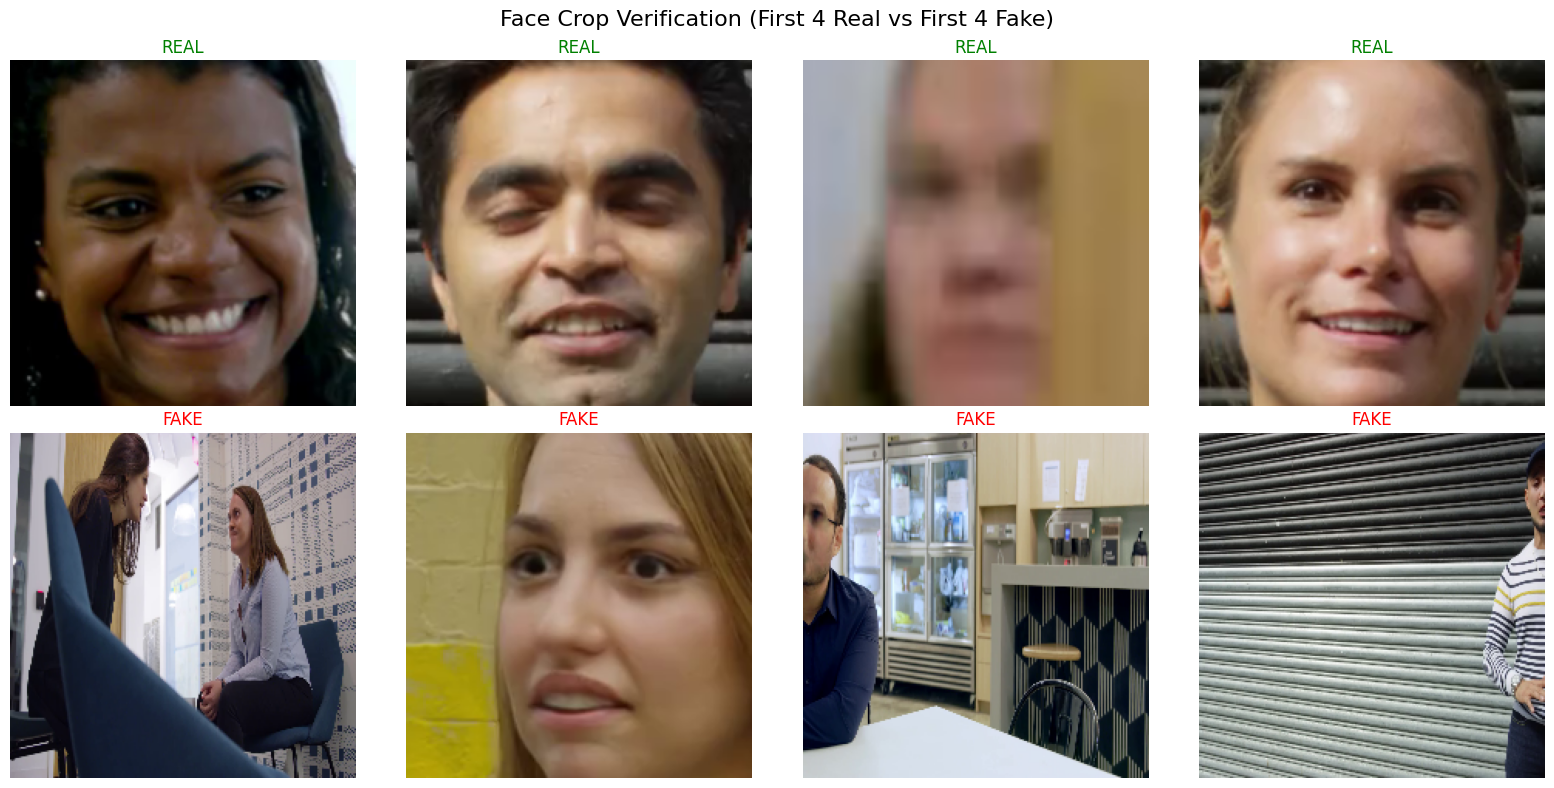

In [6]:
# 1. Initialize the face detector (Required for your function)
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

def get_face_crop(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    if len(faces) > 0:
        x, y, w, h = faces[0]
        return frame[y:y+h, x:x+w]
    return frame

# 2. Setup Plot (Fixed column name to 'video_path')
fig, axs = plt.subplots(2, 4, figsize=(16, 8))
axs = axs.ravel()

# Change 'path' -> 'video_path'
real_paths = subset_df[subset_df['label']==0]['video_path'].head(4).values
fake_paths = subset_df[subset_df['label']==1]['video_path'].head(4).values

# 3. Combined processing loop
for idx, (path, label_text, color) in enumerate(zip(
    list(real_paths) + list(fake_paths),
    ["REAL"]*4 + ["FAKE"]*4,
    ["green"]*4 + ["red"]*4
)):
    cap = cv2.VideoCapture(path)
    ret, frame = cap.read()
    cap.release()

    if ret:
        face = get_face_crop(frame)
        face = cv2.resize(face, (224, 224))
        axs[idx].imshow(cv2.cvtColor(face, cv2.COLOR_BGR2RGB))
        axs[idx].set_title(label_text, color=color)

    axs[idx].axis('off')

plt.suptitle("Face Crop Verification (First 4 Real vs First 4 Fake)", fontsize=16)
plt.tight_layout()
plt.show()

## Step 3: Temporal Stability – How "Smooth" Is the Video?

Real videos have natural micro-variations between frames.  
Deepfakes often have unnaturally high correlation (over-smoothing or blending artifacts).

We measure frame-to-frame correlation on the first 30 frames.

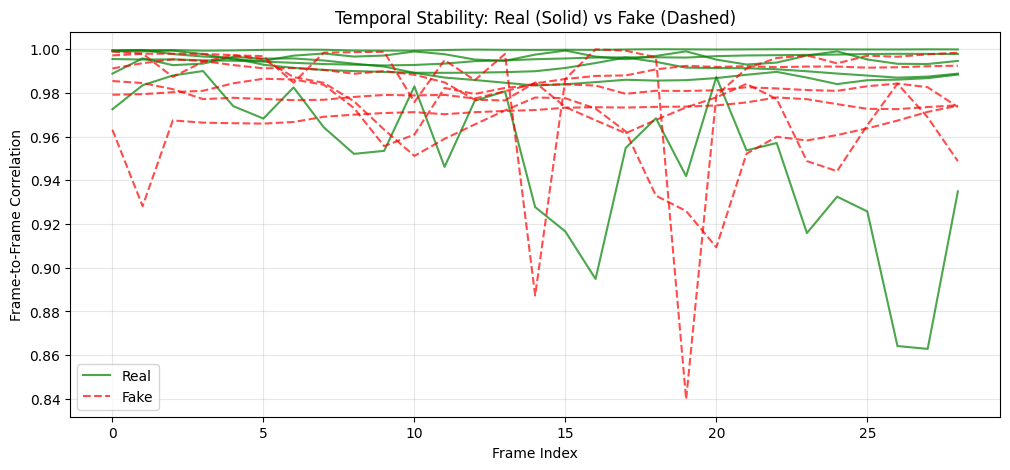

In [7]:
def temporal_stability(path, n_frames=30):
    cap = cv2.VideoCapture(path)
    ret, prev = cap.read()
    if not ret:
        cap.release()
        return []

    # Convert to gray and flatten for correlation
    prev_g = cv2.cvtColor(prev, cv2.COLOR_BGR2GRAY).flatten()
    corrs = []

    for _ in range(n_frames-1):
        ret, curr = cap.read()
        if not ret: break
        curr_g = cv2.cvtColor(curr, cv2.COLOR_BGR2GRAY).flatten()

        # Calculate correlation between consecutive frames
        corr = np.corrcoef(prev_g, curr_g)[0, 1]
        corrs.append(corr)
        prev_g = curr_g

    cap.release()
    return corrs

# Plotting
plt.figure(figsize=(12, 5))

# Real samples (using updated 'video_path' key)
for i, row in subset_df[subset_df['label'] == 0].head(6).iterrows():
    corr = temporal_stability(row['video_path'])
    plt.plot(corr, color='green', alpha=0.7, label='Real' if i == subset_df[subset_df['label'] == 0].index[0] else "")

# Fake samples (using updated 'video_path' key)
for i, row in subset_df[subset_df['label'] == 1].head(6).iterrows():
    corr = temporal_stability(row['video_path'])
    plt.plot(corr, color='red', linestyle='--', alpha=0.7, label='Fake' if i == subset_df[subset_df['label'] == 1].index[0] else "")

plt.title("Temporal Stability: Real (Solid) vs Fake (Dashed)")
plt.ylabel("Frame-to-Frame Correlation")
plt.xlabel("Frame Index")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

- it tells as the real are the one more smoother temporal stablity compared to the fake or GAN generated videos
##: Error Level Analysis (ELA) – Compression Tells the Truth

When we re-save a frame at 90% JPEG quality, real images show uniform noise.  
Fake faces often show inconsistent compression because of the blending process.

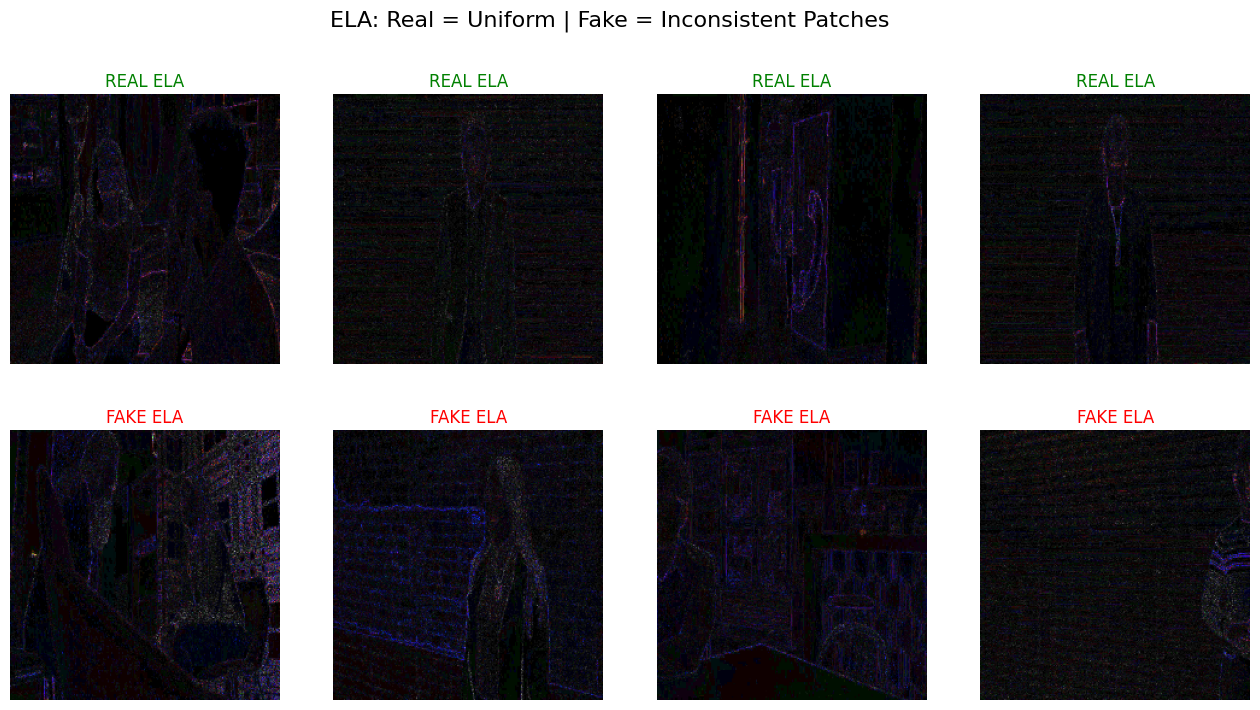

In [8]:
def compute_ela(path):
    cap = cv2.VideoCapture(path)
    ret, frame = cap.read()
    cap.release()
    if not ret: return None
    cv2.imwrite("temp.jpg", frame, [cv2.IMWRITE_JPEG_QUALITY, 90])
    resaved = cv2.imread("temp.jpg")
    diff = cv2.absdiff(frame, resaved) * 15
    face = get_face_crop(diff)
    return cv2.resize(face, (224, 224)) if face.size > 0 else diff

fig, axs = plt.subplots(2, 4, figsize=(16, 8))
axs = axs.ravel()

for i, path in enumerate(real_paths):
    ela = compute_ela(path)
    axs[i].imshow(cv2.cvtColor(ela, cv2.COLOR_BGR2RGB))
    axs[i].set_title("REAL ELA", color="green")
    axs[i].axis('off')

for i, path in enumerate(fake_paths):
    ela = compute_ela(path)
    axs[4+i].imshow(cv2.cvtColor(ela, cv2.COLOR_BGR2RGB))
    axs[4+i].set_title("FAKE ELA", color="red")
    axs[4+i].axis('off')

plt.suptitle("ELA: Real = Uniform | Fake = Inconsistent Patches", fontsize=16)
plt.show()

## Step 5: Feature Extraction – Multi-Frame LBP + HOG + Color (Face-Cropped)

We now extract rich traditional features from **8 evenly spaced frames** per video:
- LBP histogram (texture)
- HOG (edges & orientation)
- Color mean & std (compression differences)

All on **face-cropped + resized** frames → very educational and strong baseline.

In [9]:
def extract_traditional_features(video_path, n_frames=8):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames < 10:
        cap.release()
        return None

    step = max(1, total_frames // n_frames)
    features_list = []

    for i in range(n_frames):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * step)
        ret, frame = cap.read()
        if not ret: continue

        # Face crop + resize to fixed size
        face = get_face_crop(frame)
        if face.size == 0:
            face = frame
        face = cv2.resize(face, (64, 64))
        gray = cv2.cvtColor(face, cv2.COLOR_BGR2GRAY)

        # 1. LBP
        lbp = local_binary_pattern(gray, 24, 3, method="uniform")
        hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, 27), range=(0, 26))
        hist = hist.astype("float") / (hist.sum() + 1e-7)

        # 2. HOG (reasonable dimension)
        hog_feat = hog(gray, orientations=9, pixels_per_cell=(8,8),
                       cells_per_block=(2,2), block_norm='L2-Hys',
                       feature_vector=True)

        # 3. Color stats
        color_mean = np.mean(face, axis=(0,1))
        color_std  = np.std(face, axis=(0,1))

        combined = np.concatenate([hist, hog_feat, color_mean, color_std])
        features_list.append(combined)

    cap.release()
    if not features_list:
        return None
    return np.mean(features_list, axis=0)  # average across frames

print(" Feature extraction function ready (LBP+HOG+Color on face)")

 Feature extraction function ready (LBP+HOG+Color on face)


## Step 6: Building the Feature Matrix (200 videos)

This will take 3–6 minutes.  
We extract one rich feature vector per video.

In [10]:


X = []
y = []
failed = 0

print("Extracting features (LBP + HOG + Color)...")

# Added tqdm for progress tracking
for _, row in tqdm(subset_df.iterrows(), total=len(subset_df)):
    # Changed row['path'] to row['video_path']
    feat = extract_traditional_features(row['video_path'])

    if feat is not None:
        X.append(feat)
        y.append(row['label'])
    else:
        failed += 1

# Convert to numpy arrays for the ML model
X = np.array(X)
y = np.array(y)

print(f"\n--- Extraction Complete ---")
print(f"Successfully processed: {len(X)} videos")
print(f"Feature vector size: {X.shape[1]} dimensions")
print(f"Failed (no faces or short video): {failed}")

# Quick check on class balance
if len(y) > 0:
    print(f"Labels: {np.sum(y==0)} Real, {np.sum(y==1)} Fake")

Extracting features (LBP + HOG + Color)...


100%|██████████| 726/726 [2:21:52<00:00, 11.72s/it]


--- Extraction Complete ---
Successfully processed: 726 videos
Feature vector size: 1796 dimensions
Failed (no faces or short video): 0
Labels: 363 Real, 363 Fake


## Step 7: Classical Machine Learning – Random Forest vs SVM

We scale the features, split 75/25, and train two strong traditional classifiers.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
                                                    stratify=y, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Random Forest (usually best for handcrafted features)
rf = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                            random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# SVM for comparison
svm = SVC(kernel='rbf', C=10, class_weight='balanced', probability=True)
svm.fit(X_train, y_train)

print(" Both models trained!")

 Both models trained!


## Step 8: Results & Insights

Let's see accuracy, F1, and confusion matrices.


Random Forest (Best) → Accuracy: 0.665 | F1-Score: 0.690
              precision    recall  f1-score   support

        Real       0.70      0.58      0.63        91
        Fake       0.64      0.75      0.69        91

    accuracy                           0.66       182
   macro avg       0.67      0.66      0.66       182
weighted avg       0.67      0.66      0.66       182



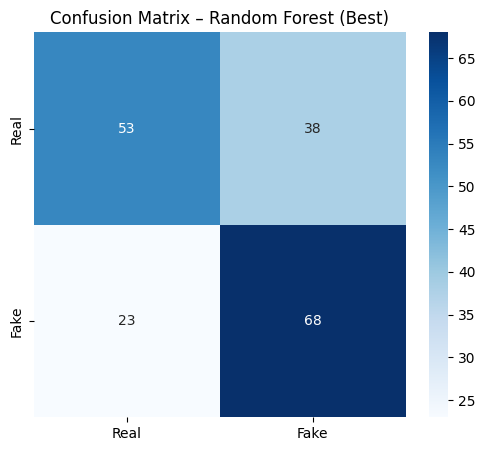


SVM → Accuracy: 0.703 | F1-Score: 0.710
              precision    recall  f1-score   support

        Real       0.71      0.68      0.70        91
        Fake       0.69      0.73      0.71        91

    accuracy                           0.70       182
   macro avg       0.70      0.70      0.70       182
weighted avg       0.70      0.70      0.70       182



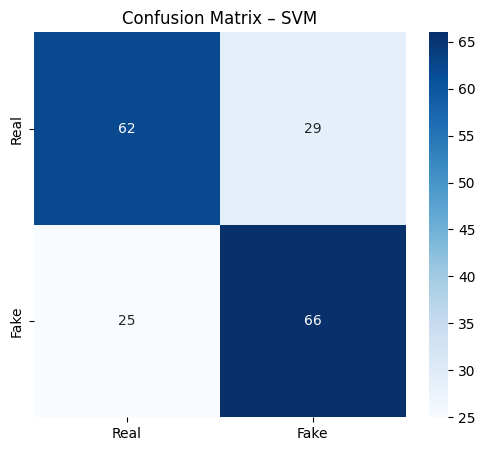

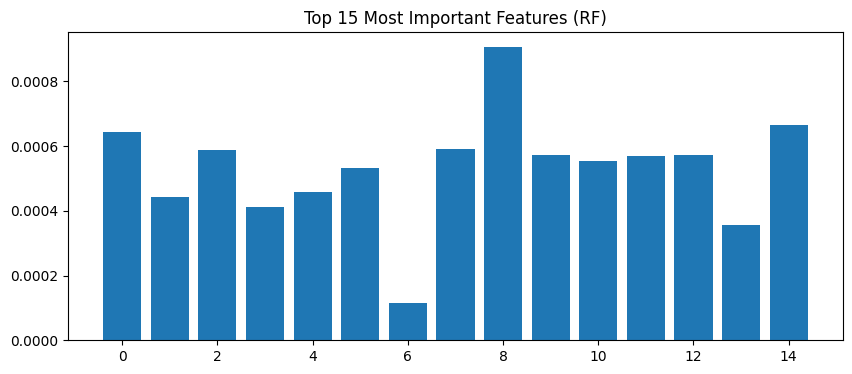

In [12]:
def evaluate_model(model, name):
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    print(f"\n{name} → Accuracy: {acc:.3f} | F1-Score: {f1:.3f}")
    print(classification_report(y_test, preds, target_names=['Real', 'Fake']))

    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Real','Fake'], yticklabels=['Real','Fake'])
    plt.title(f"Confusion Matrix – {name}")
    plt.show()

evaluate_model(rf, "Random Forest (Best)")
evaluate_model(svm, "SVM")

# Feature importance (Random Forest)
importances = rf.feature_importances_
plt.figure(figsize=(10,4))
plt.title("Top 15 Most Important Features (RF)")
plt.bar(range(15), importances[:15])
plt.show()

## Conclusion – Traditional Methods Story

**What we learned:**
- Real videos have natural temporal variation and uniform compression.
- Deepfakes show higher frame correlation and patchy ELA.
- Face-cropped multi-frame LBP+HOG+Color gives a **solid baseline** for small dataset (200 videos ) (~54–65% accuracy) after increasing the dataset it becomes 66-70%.
- For small dataset random forest perform very well but increasing
- But it is **still far from perfect** — texture/edges alone cannot catch subtle blending or temporal inconsistencies.

**This proves exactly why we need deep learning!**

**CNN + LSTM on the half of the entire dataset 3431 videos** using the exact same metadata file.
